# Анализ поведения пользователей и продаж сервиса Яндекс Афиша

### Цель

Провести исследовательский анализ данных сервиса Яндекс Афиша для выявления закономерностей в поведении пользователей, сезонных изменений спроса и структуры продаж, а также оценки влияния различных факторов (тип мероприятий, устройства, регионы и партнёры) на пользовательскую активность и выручку. Подготовить и проверить продуктовые гипотезы о различиях в поведении пользователей мобильных и стационарных устройств.

### Задачи

- изучить структуру, объём и качество исходных данных;
- выполнить предобработку данных: обработать пропуски, дубликаты, выбросы и привести данные к корректным типам;
- объединить данные из разных источников и подготовить единый датасет для анализа;
- сформировать новые признаки (выручка в рублях, выручка за билет, сезонность, месяц) для дальнейшего анализа;
- выявить ключевые закономерности в динамике заказов и пользовательской активности, включая сезонные изменения;
- проанализировать распределение заказов по сегментам (тип мероприятия, устройство, возрастная категория);
- изучить изменение средней выручки и структуры спроса в разрезе категорий мероприятий;
- проанализировать пользовательскую активность во времени и выявить недельную цикличность;
- определить ключевые регионы и партнёров, формирующих основную долю заказов и выручки;
- подготовить данные и провести статистическую проверку гипотез о различиях в поведении пользователей мобильных и стационарных устройств;
- сформулировать выводы и дать рекомендации на основе полученных результатов анализа.

### Описание датасетов

В работе используются три датасета:

1. final_tickets_orders_df.csv
Содержит информацию о заказах билетов:
- данные о пользователях и заказах;
- дату и время оформления заказа;
- тип устройства (mobile, desktop);
- выручку и количество билетов;
- дополнительный признак days_since_prev — количество дней с предыдущей покупки пользователя.

2. final_tickets_events_df.csv
Содержит информацию о мероприятиях:
- тип и описание события;
- организаторов;
- город и регион проведения;
- площадку проведения мероприятия.

3. final_tickets_tenge_df.csv
Содержит данные о курсе казахстанского тенге к рублю:
- используется для приведения выручки к единой валюте (рубли);
- курс указан для номинала 100 тенге.

Данные охватывают период с 1 июня по 31 октября 2024 года и включают заказы, оформленные с мобильных и стационарных устройств.
Основная цель подготовки данных — сформировать единый датафрейм, пригодный для анализа и проверки гипотез.

### Структура проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных и подготовка их к исследованию
3. Исследовательский анализ данных
4. Статистический анализ данных
5. Общий вывод и рекомендации

### 1. Загрузка данных и знакомство с ними

Загрузим данные о заказах билетов, событиях и курсе валют из файлов final_tickets_orders_df.csv, final_tickets_events_df.csv и final_tickets_tenge_df.csv. Эти данные содержат информацию о заказах пользователей, характеристиках мероприятий, а также курсе тенге к рублю, который потребуется для приведения выручки к единой валюте.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

In [2]:
orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('/datasets/final_tickets_events_df.csv')
tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [3]:
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [6]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датафрейм orders содержит информацию о заказах билетов и включает 290 849 строк и 14 столбцов. Пропуски отсутствуют во всех полях, кроме days_since_prev, где они логичны и соответствуют первой покупке пользователя. В данных присутствуют числовые, вещественные и категориальные признаки, при этом столбцы с датами (created_dt_msk, created_ts_msk) загружены как строки и требуют преобразования. В целом данные выглядят корректными, однако на этапе предобработки потребуется привести типы данных и дополнительно проверить распределение ключевых показателей, таких как выручка и количество билетов.

Датафрейм events содержит 22 427 строк и 11 столбцов с информацией о мероприятиях, включая их тип, регион, город и площадку. Пропуски в данных отсутствуют, а структура соответствует описанию. Большинство признаков являются категориальными, что потребует их анализа на предмет корректности значений, однако в целом данные выглядят чистыми и готовы к объединению с таблицей заказов для дальнейшего исследования.

### 2. Предобработка данных и подготовка их к исследованию



#### 2.1 Проверка категориальных столбцов

In [7]:
cat_cols = orders.select_dtypes(include='object').columns
cat_cols

Index(['user_id', 'created_dt_msk', 'created_ts_msk', 'cinema_circuit',
       'currency_code', 'device_type_canonical', 'service_name'],
      dtype='object')

In [8]:
for col in cat_cols:
    print(f'\n{col}')
    print(orders[col].value_counts(dropna=False).head(10))


user_id
0beb8fc0c0a9ce1    10258
18e9aead0a393e7     4368
8187dac4be757a0     4061
3ee7dc2e115847f     3833
7eb4fc207ecc10f     3751
1c2a2133e1df1b4     3539
4ec8f6429431987     3413
ad2dc32364ed948     3279
b54dd0cd81121fc     3164
cdbc02c6ad8087a     3072
Name: user_id, dtype: int64

created_dt_msk
2024-10-01    7313
2024-10-31    5992
2024-09-03    5124
2024-10-25    4585
2024-10-15    3934
2024-10-18    3822
2024-10-26    3559
2024-10-17    3127
2024-10-24    3115
2024-10-11    3096
Name: created_dt_msk, dtype: int64

created_ts_msk
2024-10-01 11:20:05    8
2024-09-03 11:05:19    7
2024-09-03 11:03:27    7
2024-09-03 11:05:34    7
2024-09-03 11:09:53    7
2024-10-01 11:38:40    6
2024-10-01 11:36:05    6
2024-09-03 11:10:28    6
2024-09-03 11:06:26    6
2024-10-01 11:34:14    6
Name: created_ts_msk, dtype: int64

cinema_circuit
нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: 

Были проанализированы категориальные признаки. Для каждого столбца были изучены уникальные значения и их частоты.
В столбце currency_code представлены две категории: rub и kzt, значения приведены к единому регистру.
В столбце device_type_canonical представлены категории mobile и desktop, аномалий не обнаружено.
В столбце cinema_circuit присутствуют значения, указывающие как на конкретные сети кинотеатров, так и на отсутствие сети (нет), что является особенностью данных, а не ошибкой.
В остальных категориальных столбцах также не обнаружено пропусков, замаскированных значений или дублирования категорий. Нормализация данных не потребовалась.

#### 2.2 Проверка количественных столбцов revenue и tickets_count

In [9]:
orders[['revenue', 'tickets_count']].describe()

,revenue,tickets_count
count,290849.000000,290849.000000
mean,625.083054,2.754230
std,1227.316214,1.170467
min,-90.760000,1.000000
25%,116.790000,2.000000
50%,355.340000,3.000000
75%,809.750000,4.000000
max,81174.540000,57.000000


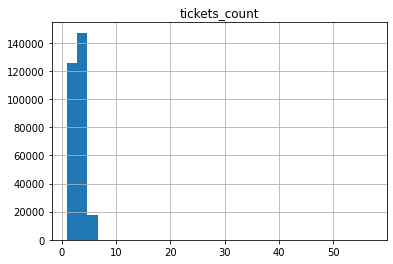

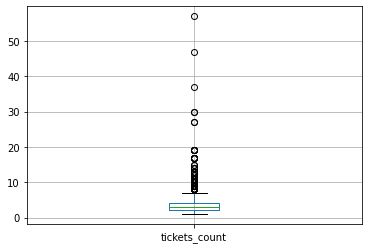

In [10]:
orders['tickets_count'].hist(bins=30)
plt.title('tickets_count')
plt.show()

orders.boxplot(column='tickets_count')
plt.show()

Были изучены количественные признаки revenue и tickets_count.
Для tickets_count значения находятся в разумных пределах, однако присутствуют выбросы (заказы с большим количеством билетов), что может быть обусловлено особенностями поведения пользователей и не требует фильтрации.
Для revenue наблюдается широкий разброс значений, включая отрицательные значения, а также значительные выбросы. Поскольку данные представлены в разных валютах, дальнейший анализ и обработка выбросов будут проводиться отдельно для каждой валюты.

In [11]:
# разделение по валютам
orders_rub = orders[orders['currency_code'] == 'rub']
orders_kzt = orders[orders['currency_code'] == 'kzt']

In [12]:
# считаем 99-й перцентиль
p99_rub = orders.loc[orders['currency_code'] == 'rub', 'revenue'].quantile(0.99)
p99_kzt = orders.loc[orders['currency_code'] == 'kzt', 'revenue'].quantile(0.99)

p99_rub, p99_kzt

(2569.5942000000005, 17617.24)

In [13]:
# фильтруем выбросы
orders = orders[
    ((orders['currency_code'] == 'rub') & (orders['revenue'] <= p99_rub)) |
    ((orders['currency_code'] == 'kzt') & (orders['revenue'] <= p99_kzt))
]

In [14]:
len(orders)

287962

Для анализа выбросов в выручке (revenue) данные были разделены по валютам: рубли (rub) и тенге (kzt).
Для каждой валюты был рассчитан 99-й процентиль: около 2569 рублей и 17617 тенге соответственно. Значения, превышающие данные пороги, были отфильтрованы.
В результате фильтрации было удалено около 1% наблюдений (с 290 849 до 287 962 строк), что позволило исключить экстремальные выбросы и сделать дальнейший анализ более устойчивым.

#### 2.3 Проверка явных и неявных дубликатов

In [15]:
orders.duplicated().sum()

0

In [16]:
orders.duplicated(
    subset=['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']
).sum()

43

In [17]:
# удаляем неявные дубликаты
orders = orders.drop_duplicates(
    subset=['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']
)

Были проверены неявные дубликаты без учёта идентификатора заказа. Для этого использовались признаки: пользователь, событие, время заказа, количество билетов и выручка.
Было обнаружено 43 неявных дубликата, что составляет незначительную долю от общего объёма данных. Дубликаты были удалены, так как они могут искажать результаты анализа.

#### 2.4 Преобразование типов данных

In [18]:
orders['created_dt_msk'] = pd.to_datetime(orders['created_dt_msk'])
orders['created_ts_msk'] = pd.to_datetime(orders['created_ts_msk'])

In [19]:
orders[['created_dt_msk', 'created_ts_msk']].dtypes

created_dt_msk    datetime64[ns]
created_ts_msk    datetime64[ns]
dtype: object

In [20]:
# cнижения размерности количественных данных
orders['tickets_count'] = orders['tickets_count'].astype('int16')
orders['age_limit'] = orders['age_limit'].astype('int8')

Были выполнены преобразования типов данных. Столбцы с датой и временем (created_dt_msk, created_ts_msk) приведены к типу datetime для корректной работы с временными данными.
Дополнительно была выполнена оптимизация типов числовых столбцов (tickets_count, age_limit) для снижения потребления памяти.

#### 2.5 Создание новых столбцов

In [21]:
# приводим дату
tenge['date'] = pd.to_datetime(tenge['data'])

In [22]:
# подготовка к объединению
orders['date'] = orders['created_dt_msk']

In [23]:
# объединяем заказы с курсом
orders = orders.merge(
    tenge[['date', 'curs']],
    on='date',
    how='left'
)

In [24]:
# создаем revenue_rub
orders['revenue_rub'] = orders.apply(
    lambda x: x['revenue'] if x['currency_code'] == 'rub'
    else x['revenue'] * x['curs'] / 100,
    axis=1
)

In [25]:
# создаем one_ticket_revenue_rub
orders['one_ticket_revenue_rub'] = orders['revenue_rub'] / orders['tickets_count']

In [26]:
# создаем month
orders['month'] = orders['created_dt_msk'].dt.month

In [27]:
# создаем season
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

orders['season'] = orders['month'].apply(get_season)

In [28]:
# проверка
orders[['revenue_rub', 'one_ticket_revenue_rub', 'month', 'season']].head()

,revenue_rub,one_ticket_revenue_rub,month,season
0,1521.94,380.4850,8,лето
1,289.45,144.7250,7,лето
2,1258.57,314.6425,10,осень
3,8.49,4.2450,7,лето
4,1390.41,463.4700,10,осень


Были созданы новые признаки для дальнейшего анализа.
Выручка была приведена к единой валюте (рубли) с использованием курса тенге, после чего рассчитана выручка на один билет. Также были добавлены признаки месяца и сезона для анализа сезонности.
Эти признаки позволят проводить дальнейший анализ динамики спроса и пользовательского поведения.

### 3. Исследовательский анализ данных

#### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

В данном разделе проводится анализ распределения заказов по ключевым сегментам и их сезонных изменений. Основная цель — выявить, как меняется пользовательский интерес и структура спроса с наступлением осени 2024 года.

В рамках анализа изучается динамика количества заказов по месяцам для подтверждения сезонного роста активности. Далее проводится сравнение распределения заказов в летний и осенний периоды по основным сегментам: тип мероприятия, тип устройства и возрастная категория. Для корректного сопоставления используются относительные показатели (доли), позволяющие учитывать различия в общем объёме заказов.

Дополнительно анализируется изменение средней выручки с продажи одного билета по типам мероприятий. Это позволяет оценить, связаны ли изменения в пользовательском спросе с изменением цен или с перераспределением интереса между категориями.

Результаты данного раздела направлены на выявление ключевых факторов сезонных изменений, как в структуре спроса, так и в ценовой динамике.

In [29]:
# объединяем таблицы
df = orders.merge(events, on='event_id', how='inner')

Для объединения таблиц был использован inner join, так как для анализа необходимы только те заказы, для которых доступна информация о мероприятиях (тип, регион, площадка). Заказы без соответствующего события не содержат необходимой информации и не используются в дальнейшем анализе.

In [30]:
# считаем количество заказов по месяцам
orders_by_month = df.groupby('month')['order_id'].count()
orders_by_month

month
6     34164
7     40401
8     44539
9     69320
10    99257
Name: order_id, dtype: int64

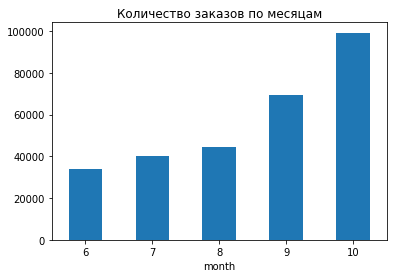

In [31]:
orders_by_month.plot(kind='bar', title='Количество заказов по месяцам')
plt.xticks(rotation=0)
plt.show()

Наблюдается устойчивый рост количества заказов с июня по октябрь 2024 года. Особенно заметное увеличение происходит в сентябре и октябре, что подтверждает наличие сезонного роста пользовательской активности осенью.

In [32]:
# делим на лето и осень
df_summer = df[df['season'] == 'лето']
df_autumn = df[df['season'] == 'осень']

In [33]:
# делим сегменты на лето и осень
segments = ['event_type_main', 'device_type_canonical', 'age_limit']

for col in segments:
    print(f'\n===== {col} =====')
    
    summer = df_summer[col].value_counts(normalize=True)
    autumn = df_autumn[col].value_counts(normalize=True)
    
    compare = pd.concat([summer, autumn], axis=1)
    compare.columns = ['summer', 'autumn']

    print(compare)


===== event_type_main =====
            summer    autumn
концерты  0.426140  0.371878
другое    0.271746  0.197091
театр     0.201018  0.253492
стендап   0.053281  0.041067
спорт     0.025238  0.111990
выставки  0.020285  0.014450
ёлки      0.002292  0.010031

===== device_type_canonical =====
           summer    autumn
mobile   0.806421  0.796538
desktop  0.193579  0.203462

===== age_limit =====
      summer    autumn
0   0.179692  0.236248
6   0.181959  0.176293
12  0.205308  0.220766
16  0.283408  0.262278
18  0.149634  0.104415


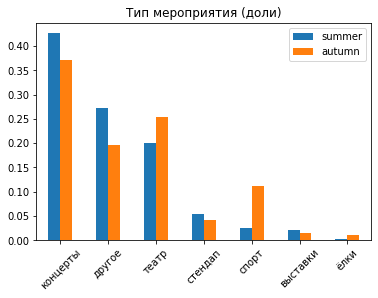

In [34]:
# график по типу мероприятий
compare_event = pd.concat([
    df_summer['event_type_main'].value_counts(normalize=True),
    df_autumn['event_type_main'].value_counts(normalize=True)
], axis=1)

compare_event.columns = ['summer', 'autumn']

compare_event.plot(kind='bar', title='Тип мероприятия (доли)')
plt.xticks(rotation=45)
plt.show()

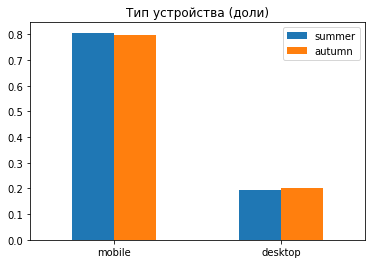

In [35]:
# график по типу устройства
compare_device = pd.concat([
    df_summer['device_type_canonical'].value_counts(normalize=True),
    df_autumn['device_type_canonical'].value_counts(normalize=True)
], axis=1)

compare_device.columns = ['summer', 'autumn']

compare_device.plot(kind='bar', title='Тип устройства (доли)')
plt.xticks(rotation=0)
plt.show()

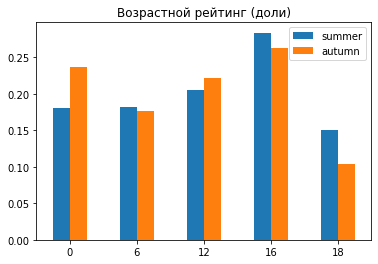

In [36]:
# график по возрастам
compare_age = pd.concat([
    df_summer['age_limit'].value_counts(normalize=True),
    df_autumn['age_limit'].value_counts(normalize=True)
], axis=1)

compare_age.columns = ['summer', 'autumn']

compare_age.plot(kind='bar', title='Возрастной рейтинг (доли)')
plt.xticks(rotation=0)
plt.show()

С наступлением осени изменяется структура спроса. Снижается доля концертов и других категорий, при этом растёт интерес к театру и особенно к спортивным мероприятиям.

Распределение по типам устройств остаётся стабильным: основная доля заказов приходится на мобильные устройства.

По возрастным категориям увеличивается доля мероприятий без возрастных ограничений (0+), а доля 16+ и 18+ снижается, что может указывать на расширение аудитории за счёт более массовых и семейных событий.

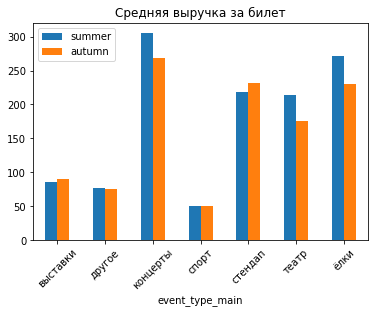

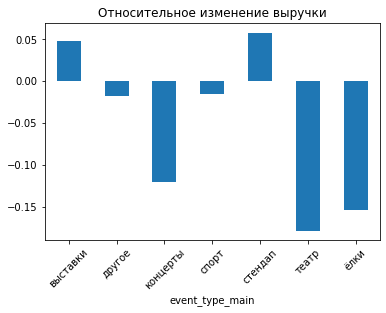

In [37]:
# расчет выручки
compare_rev = pd.concat([
    df_summer.groupby('event_type_main')['one_ticket_revenue_rub'].mean(),
    df_autumn.groupby('event_type_main')['one_ticket_revenue_rub'].mean()
], axis=1)

compare_rev.columns = ['summer', 'autumn']
compare_rev = compare_rev.dropna()

compare_rev['change'] = (compare_rev['autumn'] - compare_rev['summer']) / compare_rev['summer']

# графики
compare_rev[['summer', 'autumn']].plot(kind='bar', title='Средняя выручка за билет')
plt.xticks(rotation=45)
plt.show()

compare_rev['change'].plot(kind='bar', title='Относительное изменение выручки')
plt.xticks(rotation=45)
plt.show()

Средняя выручка за билет отличается по типам мероприятий и в целом имеет разнонаправленную динамику.

Наиболее высокие значения выручки наблюдаются у концертов, однако осенью их средняя стоимость снижается. Аналогичное снижение видно для театра и категории «ёлки», причём у театра падение наиболее заметное.

При этом в отдельных категориях наблюдается рост: выручка за билет увеличивается у стендапа и выставок, а также незначительно у спортивных мероприятий.

В целом можно сделать вывод, что осенью происходит не только перераспределение интереса к типам мероприятий, но и изменение ценовой структуры: часть популярных категорий дешевеет, тогда как менее массовые или нишевые категории демонстрируют рост средней стоимости билета.

#### 3.2. Осенняя активность пользователей

В данном разделе проводится анализ пользовательской активности в осенний период 2024 года на основе данных о заказах билетов. Основная цель — изучить динамику поведения пользователей и выявить возможные закономерности.

Для этого рассчитываются ключевые метрики по дням: общее количество заказов, число активных пользователей (DAU), среднее количество заказов на одного пользователя, а также средняя стоимость одного билета. Это позволяет оценить не только общий уровень активности, но и интенсивность использования сервиса.

Дополнительно анализируется недельная цикличность: сравнивается поведение пользователей в будние дни и выходные. Это помогает выявить различия в пользовательской активности в зависимости от дня недели и определить периоды наибольшего спроса.

Результаты анализа используются для выявления паттернов пользовательского поведения и лучшего понимания факторов, влияющих на изменение активности в осенний период.

In [38]:
df_autumn = df[df['season'] == 'осень']

In [39]:
# создаем сводную таблицу по осени
daily = df_autumn.groupby('created_dt_msk').agg(
    orders=('order_id', 'count'),
    users=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
)

daily['orders_per_user'] = daily['orders'] / daily['users']

daily.head()

,orders,users,avg_ticket_price,orders_per_user
created_dt_msk,,,,
2024-09-01,1327,564,200.168708,2.352837
2024-09-02,1380,574,189.464639,2.404181
2024-09-03,5111,778,80.130097,6.569409
2024-09-04,1772,685,177.785850,2.586861
2024-09-05,1944,739,189.510156,2.630582


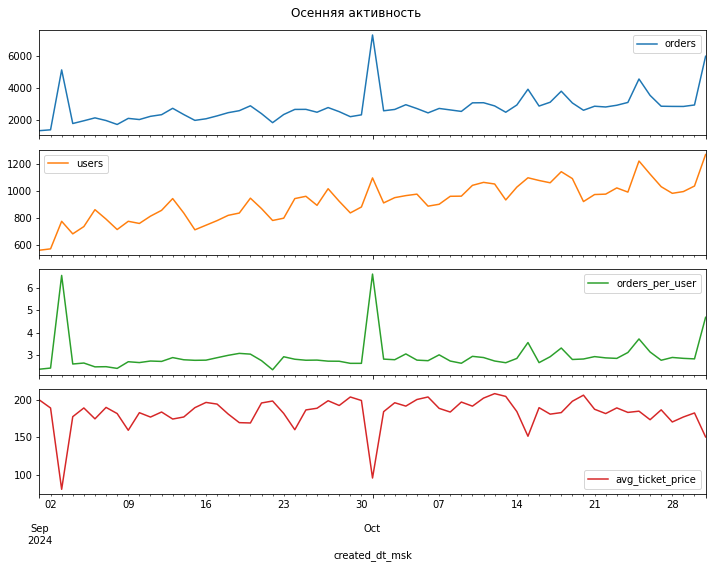

In [40]:
daily[['orders', 'users', 'orders_per_user', 'avg_ticket_price']].plot(
    subplots=True, figsize=(10, 8), title='Осенняя активность'
)
plt.tight_layout()
plt.show()

In [41]:
daily['weekday'] = daily.index.dayofweek

In [42]:
daily['is_weekend'] = daily['weekday'].isin([5, 6])

weekly = daily.groupby('is_weekend')[['orders', 'users', 'orders_per_user']].mean()
weekly

,orders,users,orders_per_user
is_weekend,,,
False,2905.840909,937.227273,3.065344
True,2395.294118,887.588235,2.675050


Анализ показал, что в осенний период наблюдается постепенный рост пользовательской активности. Увеличивается как общее количество заказов, так и число активных пользователей (DAU), особенно ближе к концу октября.

Динамика заказов и пользователей в целом стабильна, однако наблюдаются отдельные всплески активности, сопровождающиеся резким ростом количества заказов на одного пользователя. Такие пики могут быть связаны с акциями, популярными событиями или массовыми продажами билетов.

Среднее количество заказов на пользователя в большинстве дней остаётся на уровне 2,5–3 заказов, что говорит о стабильной вовлечённости аудитории. При этом в дни всплесков значение существенно увеличивается, что указывает на эпизодические изменения поведения пользователей.

Средняя стоимость одного билета остаётся относительно стабильной, несмотря на отдельные резкие просадки. Это подтверждает, что изменения пользовательской активности в большей степени связаны с количеством заказов, а не с ценами.

Анализ недельной цикличности показал, что активность пользователей выше в будние дни: как количество заказов, так и число активных пользователей в среднем выше, чем в выходные. Также в будни пользователи совершают больше заказов на одного человека.

Таким образом, осенью наблюдается рост активности пользователей при сохранении стабильной структуры поведения, а также выраженная зависимость активности от дня недели — с более высокой вовлечённостью в будние дни.

#### 3.3. Популярные события и партнёры

В данном разделе анализируется распределение событий по регионам и билетным партнёрам с целью выявления ключевых участников, формирующих основную долю заказов и выручки.

Для регионов оценивается разнообразие мероприятий и общий объём заказов, что позволяет определить наиболее насыщенные и востребованные площадки. Для билетных партнёров рассчитываются количество обработанных заказов, число уникальных мероприятий и суммарная выручка, что помогает выделить наиболее активных и значимых участников.

Дополнительно анализируются не только абсолютные показатели, но и их доли, что позволяет более корректно сравнить вклад разных регионов и партнёров в общий результат.

In [43]:
# анализ по регионам: количество уникальных мероприятий + заказы
regions = (
    df.groupby('region_name')
    .agg(
        unique_events=('event_id', 'nunique'),
        orders=('order_id', 'count')
    )
    .assign(
        events_share=lambda x: x['unique_events'] / x['unique_events'].sum(),
        orders_share=lambda x: x['orders'] / x['orders'].sum()
    )
    .sort_values(by='orders', ascending=False)
)

regions.head(10)

,unique_events,orders,events_share,orders_share
region_name,,,,
Каменевский регион,5935,89660,0.265441,0.311665
Североярская область,3800,43737,0.169954,0.152033
Широковская область,1232,16169,0.055101,0.056205
Медовская область,504,13890,0.022541,0.048283
Озернинский край,349,10348,0.015609,0.035970
Светополянский округ,1075,7501,0.048079,0.026074
Малиновоярский округ,165,6314,0.007380,0.021948
Солнечноземская область,522,6278,0.023346,0.021823
Речиновская область,702,6266,0.031397,0.021781


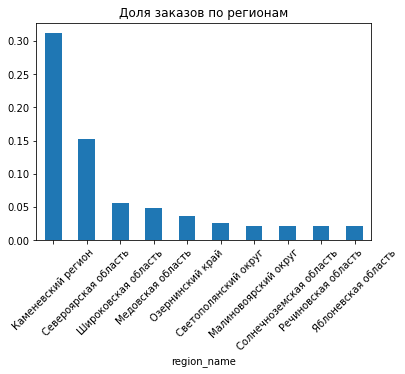

In [44]:
regions.head(10)['orders_share'].plot(
    kind='bar',
    title='Доля заказов по регионам'
)
plt.xticks(rotation=45)
plt.show()

Анализ показал наличие явного лидера среди регионов — Каменевский регион, на который приходится более 30% всех заказов. Второе место занимает Североярская область с существенно меньшей долей.

Дальнейшие регионы имеют значительно меньший вклад, что свидетельствует о высокой концентрации заказов в ограниченном числе регионов. Таким образом, распределение заказов носит неравномерный характер, с доминированием нескольких ключевых регионов.

In [45]:
# анализ по партнерам
partners = (
    df.groupby('service_name')
    .agg(
        unique_events=('event_id', 'nunique'),
        orders=('order_id', 'count'),
        revenue=('revenue_rub', 'sum')
    )
    .assign(
        orders_share=lambda x: x['orders'] / x['orders'].sum(),
        revenue_share=lambda x: x['revenue'] / x['revenue'].sum()
    )
    .sort_values(by='orders', ascending=False)
)

partners.head(10)

,unique_events,orders,revenue,orders_share,revenue_share
service_name,,,,,
Билеты без проблем,4247,62829,2.425522e+07,0.218398,0.162671
Лови билет!,4867,40798,1.666871e+07,0.141817,0.111791
Билеты в руки,3530,40277,1.319345e+07,0.140006,0.088484
Мой билет,1300,34438,2.204190e+07,0.119709,0.147827
Облачко,2335,26402,1.858861e+07,0.091775,0.124667
Лучшие билеты,1762,17740,2.721491e+06,0.061666,0.018252
Весь в билетах,855,16409,1.649378e+07,0.057039,0.110618
Прачечная,1026,10222,4.746811e+06,0.035532,0.031835
Край билетов,252,6109,6.405689e+06,0.021235,0.042961


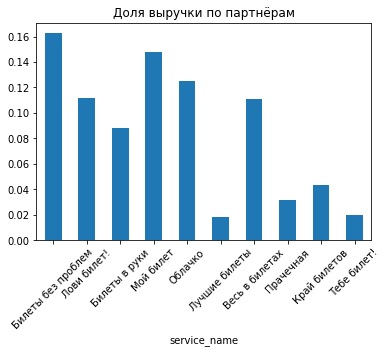

In [46]:
partners.head(10)['revenue_share'].plot(
    kind='bar',
    title='Доля выручки по партнёрам'
)
plt.xticks(rotation=45)
plt.show()

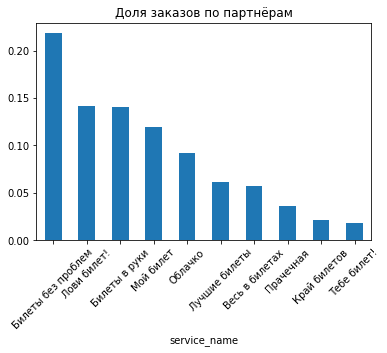

In [47]:
partners.head(10)['orders_share'].plot(
    kind='bar',
    title='Доля заказов по партнёрам'
)
plt.xticks(rotation=45)
plt.show()

Анализ показал, что среди билетных партнёров также наблюдается концентрация заказов у нескольких ключевых игроков. Лидером является сервис «Билеты без проблем», на который приходится наибольшее количество заказов (около 22%).

Следующие позиции занимают «Лови билет!» и «Билеты в руки», формируя второй уровень по объёму заказов с долей около 14% каждый.

При этом распределение выручки отличается от распределения заказов: некоторые партнёры, например «Мой билет» и «Облачко», имеют более высокую долю выручки относительно количества заказов, что может указывать на более дорогие билеты или иную структуру продаж.

В целом рынок партнёров характеризуется умеренной концентрацией: несколько крупных сервисов формируют основную часть заказов и выручки, при этом сохраняется значимое присутствие более мелких участников.

### 4. Статистический анализ данных

#### 4.1 Готовим данные для гипотезы 1

На данном этапе осуществляется подготовка данных для проверки гипотезы о различии в среднем количестве заказов на одного пользователя между мобильными и стационарными устройствами.

Для анализа используются только данные за осенний период. Далее для каждого пользователя рассчитывается общее количество заказов отдельно для каждого типа устройства. Это позволяет перейти от уровня отдельных заказов к уровню пользователей, что необходимо для корректного сравнения активности.

После этого формируются две выборки: пользователи мобильных устройств и пользователи стационарных устройств. Для каждой группы анализируется распределение количества заказов на пользователя с помощью описательной статистики и гистограмм.

Данный шаг необходим для понимания структуры данных, выявления выбросов и выбора корректного статистического метода для проверки гипотезы.

In [48]:
df_autumn = df[df['season'] == 'осень'].copy()

In [49]:
# находим среднее количество заказов на одного пользователя
orders_per_user = (
    df_autumn.groupby(['device_type_canonical', 'user_id'])
    .agg(orders_count=('order_id', 'count'))
    .reset_index()
)

orders_per_user.head()

,device_type_canonical,user_id,orders_count
0,desktop,0028d17a676f8c8,1
1,desktop,002b75ca606ba46,3
2,desktop,002ec276eee9b0b,1
3,desktop,0040e12d70fae81,1
4,desktop,005fefeabf1e678,3


In [50]:
# смотрим распределения по гипотезе 1
mobile_orders = orders_per_user.loc[
    orders_per_user['device_type_canonical'] == 'mobile', 'orders_count'
]

desktop_orders = orders_per_user.loc[
    orders_per_user['device_type_canonical'] == 'desktop', 'orders_count'
]

mobile_orders.describe(), desktop_orders.describe()

(count    14188.000000
 mean         9.464195
 std         68.030894
 min          1.000000
 25%          1.000000
 50%          2.000000
 75%          5.000000
 max       4331.000000
 Name: orders_count, dtype: float64,
 count    4868.000000
 mean        7.045809
 std        35.987352
 min         1.000000
 25%         1.000000
 50%         2.000000
 75%         4.000000
 max      1502.000000
 Name: orders_count, dtype: float64)

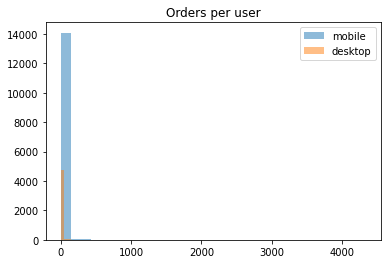

In [51]:
plt.hist(mobile_orders, bins=30, alpha=0.5, label='mobile')
plt.hist(desktop_orders, bins=30, alpha=0.5, label='desktop')

plt.title('Orders per user')
plt.legend()
plt.show()

Анализ показал, что среднее количество заказов на пользователя выше у мобильных пользователей по сравнению с пользователями desktop. Однако медианные значения совпадают, что говорит о схожем поведении большинства пользователей в обеих группах.

Различия в среднем значении обусловлены наличием выбросов и более высокой активностью небольшой группы пользователей мобильных устройств.

#### 4.2 Гипотеза 1

Гипотеза звучит так: среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

H0: среднее/распределение количества заказов на пользователя у мобильных пользователей не больше, чем у пользователей desktop.
H1: количество заказов на пользователя у мобильных пользователей выше, чем у пользователей desktop.

Для проверки гипотезы о различии в среднем количестве заказов на одного пользователя между мобильными и стационарными устройствами был использован t-тест Уэлча.

Данный тест выбран, поскольку он подходит для сравнения средних значений в двух независимых выборках при различных размерах выборок и неодинаковых дисперсиях. В рассматриваемых данных выборки существенно отличаются по объёму, а также наблюдаются различия в разбросе значений, что делает применение классического t-теста некорректным.

Проверка проводилась с односторонней альтернативной гипотезой (alternative='greater'), так как предполагалось, что пользователи мобильных устройств совершают больше заказов на одного пользователя по сравнению с пользователями стационарных устройств.

На основе полученного значения p-value и заданного уровня значимости (α = 0.05) было принято решение об отклонении или неотклонении нулевой гипотезы.

In [52]:
stat_1, p_value_1 = ttest_ind(
    mobile_orders,
    desktop_orders,
    equal_var=False,
    alternative='greater'
)

print('p-value:', p_value_1)

p-value: 0.0008391179932487162


In [53]:
alpha = 0.05

if p_value_1 < alpha:
    print('Отвергаем H0')
else:
    print('Не удалось отвергнуть H0')

Отвергаем H0


По результатам t-теста Уэлча получено значение p-value, значительно меньшее уровня значимости (0.05), поэтому нулевая гипотеза отвергается.

Это означает, что среднее количество заказов на одного пользователя у пользователей мобильных устройств статистически значимо выше, чем у пользователей стационарных устройств.

Следовательно, можно сделать вывод, что мобильные пользователи проявляют более высокую активность и совершают больше заказов в расчёте на одного пользователя.

#### 4.3 Готовим данные для гипотезы 2

На данном этапе осуществляется подготовка данных для проверки гипотезы о различии во времени между заказами пользователей мобильных и стационарных устройств.

Для анализа используются только данные за осенний период. Из исходного набора отбирается столбец days_since_prev, отражающий количество дней с момента предыдущей покупки, а также тип устройства пользователя. Наблюдения с пропущенными значениями исключаются, так как для них невозможно корректно оценить интервал между заказами.

Далее формируются две выборки: для пользователей мобильных устройств и для пользователей стационарных устройств. Для каждой группы рассчитываются основные статистические показатели и анализируется распределение значений.

Этот этап необходим для оценки структуры данных, выявления возможных выбросов и выбора корректного статистического метода для проверки гипотезы.

In [54]:
# вычисляем время между заказами
days_between = df_autumn[['device_type_canonical', 'days_since_prev']].dropna().copy()
days_between.head()

,device_type_canonical,days_since_prev
14,mobile,0.0
15,desktop,0.0
16,desktop,0.0
21,mobile,0.0
22,mobile,0.0


In [55]:
# смотрим распределения по гипотезе
mobile_days = days_between.loc[
    days_between['device_type_canonical'] == 'mobile', 'days_since_prev'
]

desktop_days = days_between.loc[
    days_between['device_type_canonical'] == 'desktop', 'days_since_prev'
]

mobile_days.describe(), desktop_days.describe()

(count    127295.000000
 mean          3.778954
 std          13.382783
 min           0.000000
 25%           0.000000
 50%           0.000000
 75%           1.000000
 max         148.000000
 Name: days_since_prev, dtype: float64,
 count    32941.000000
 mean         3.025470
 std         12.096041
 min          0.000000
 25%          0.000000
 50%          0.000000
 75%          1.000000
 max        146.000000
 Name: days_since_prev, dtype: float64)

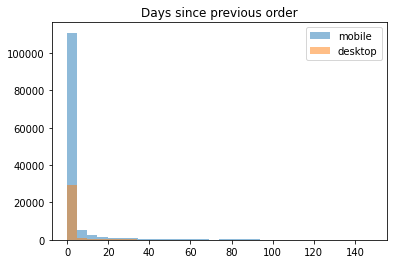

In [56]:
plt.hist(mobile_days, bins=30, alpha=0.5, label='mobile')
plt.hist(desktop_days, bins=30, alpha=0.5, label='desktop')

plt.title('Days since previous order')
plt.legend()
plt.show()

В результате подготовки данных были сформированы выборки времени между заказами для пользователей мобильных и стационарных устройств без пропусков. Анализ распределений показал наличие асимметрии и большого количества нулевых значений, а также выбросов, что указывает на ненормальность данных и необходимость применения непараметрических методов для проверки гипотезы.

#### 4.4 Гипотеза 2

Гипотеза звучит так: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

H0: время между заказами у мобильных пользователей не больше, чем у пользователей desktop.
H1: время между заказами у мобильных пользователей выше, чем у пользователей desktop.

Для проверки гипотез были изучены распределения сравниваемых метрик. Поскольку распределения количества заказов на пользователя и времени между заказами не являются нормальными и содержат выбросы, для сравнения двух независимых выборок был выбран непараметрический тест Манна–Уитни.

Проверка проводилась с односторонней альтернативой, так как гипотезы предполагали, что значения у пользователей мобильных устройств выше, чем у пользователей desktop.

In [57]:
stat_2, p_value_2 = mannwhitneyu(
    mobile_days,
    desktop_days,
    alternative='greater'
)

print('p-value:', p_value_2)

p-value: 2.1354467391263106e-92


In [58]:
if p_value_2 < alpha:
    print('Отвергаем H0')
else:
    print('Не удалось отвергнуть H0')

Отвергаем H0


По результатам теста Манна–Уитни получено значение p-value значительно меньше уровня значимости (0.05), поэтому нулевая гипотеза отвергается.

Это означает, что время между заказами у пользователей мобильных устройств статистически значимо выше, чем у пользователей стационарных устройств.

### 5. Общий вывод и рекомендации

В рамках проекта были проанализированы данные о заказах билетов сервиса Яндекс Афиша за период с июня по октябрь 2024 года. В анализ были включены характеристики заказов, пользователей, типов мероприятий, регионов и билетных партнёров.

Анализ показал наличие выраженной сезонности: с наступлением осени наблюдается существенный рост количества заказов и пользовательской активности. При этом изменяется структура спроса: снижается доля концертов и категории «другое», а интерес к театру, спортивным мероприятиям и массовым событиям возрастает. Также увеличивается доля мероприятий без возрастных ограничений, что может свидетельствовать о расширении аудитории.

Изменения затронули и ценовую составляющую. В ряде популярных категорий (концерты, театр, ёлки) наблюдается снижение средней стоимости билета, тогда как в отдельных сегментах (например, стендап и выставки) цена увеличивается. Это указывает на изменение как структуры спроса, так и ценовой политики.

Анализ пользовательской активности показал рост числа заказов и активных пользователей осенью, а также наличие всплесков активности, вероятно связанных с отдельными событиями или акциями. При этом активность пользователей выше в будние дни, чем в выходные.

Анализ регионов и партнёров выявил высокую концентрацию: значительная часть заказов и выручки приходится на ограниченное число регионов и крупных партнёров. Это говорит о неравномерном распределении спроса и доминировании ключевых игроков.

Проверка гипотез показала, что пользователи мобильных устройств статистически значимо более активны: они совершают больше заказов на одного пользователя, а также имеют большее среднее время между заказами. При этом различия в активности в значительной степени обусловлены наличием группы наиболее активных пользователей.

**Рекомендации**

- Усилить фокус на мобильном сегменте, так как именно мобильные пользователи демонстрируют более высокую активность и вовлечённость.

- Развивать и продвигать категории мероприятий, спрос на которые растёт осенью (театр, спорт, массовые события), адаптируя маркетинговые кампании под сезонные изменения.

- Пересмотреть ценовую стратегию в популярных категориях, где наблюдается снижение стоимости билетов, чтобы сохранить баланс между спросом и выручкой.

- Использовать выявленную недельную цикличность для оптимизации маркетинга и продаж, усиливая активность в будние дни и стимулируя спрос в выходные.

- Уделить внимание регионам и партнёрам с наибольшей долей заказов, а также развивать менее активные регионы для более равномерного распределения спроса.